# Analysys notebook 2
This notebook contains the report of the analysis of the full dataset, which includes the NLP part of the project.


In [42]:
# Set warnings off
import warnings
warnings.filterwarnings("ignore")


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
# load dataset
df = pd.read_csv("../dataset/guardian_headlines_2019_2025_processed.csv")
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek

In [45]:
df.head()

,date,idx,n_headlines_day,authors,headline,topics,year,gender,sentiment,sentiment_score,month,day_of_week
0,2019-01-01,1,22,No author found,Asia and Australia usher in new year with huge...,"World news,New year,Hong Kong,Taiwan,South Kor...",2019,No name provided,POSITIVE,0.999702,1,1
1,2019-01-01,2,22,No author found,"Identity, culture and definitions of Jewishness","Judaism,Religion,World news,Race,Jean-Paul Sar...",2019,No name provided,POSITIVE,0.996458,1,1
2,2019-01-01,3,22,No author found,The messy history of first-wave feminism,"Feminism,Emmeline Pankhurst,Women in politics,...",2019,No name provided,NEGATIVE,0.993136,1,1
3,2019-01-01,4,22,No author found,The Foreign Office did not have a hand in my r...,"Iran,Middle East and north Africa,Yemen,Saudi ...",2019,No name provided,NEGATIVE,0.999457,1,1
4,2019-01-01,5,22,Akshata Rao,Tower block collapse in Russia leaves four dea...,"Russia,Europe,World news",2019,unknown,NEGATIVE,0.999395,1,1


In [50]:
# Assign a sign to the sentiment
# Replace POSITIVE by +1 and NEGATIVE by -1
df['sentiment_signed'] = df['sentiment'].replace(['POSITIVE', 'NEGATIVE'], [1, -1])

df['sentiment_score_signed'] = df['sentiment_score'] * df['sentiment_signed']
df.head(10)

,date,idx,n_headlines_day,authors,headline,topics,year,gender,sentiment,sentiment_score,month,day_of_week,sentiment_signed,sentiment_score_signed
0,2019-01-01,1,22,No author found,Asia and Australia usher in new year with huge...,"World news,New year,Hong Kong,Taiwan,South Kor...",2019,No name provided,POSITIVE,0.999702,1,1,1,0.999702
1,2019-01-01,2,22,No author found,"Identity, culture and definitions of Jewishness","Judaism,Religion,World news,Race,Jean-Paul Sar...",2019,No name provided,POSITIVE,0.996458,1,1,1,0.996458
2,2019-01-01,3,22,No author found,The messy history of first-wave feminism,"Feminism,Emmeline Pankhurst,Women in politics,...",2019,No name provided,NEGATIVE,0.993136,1,1,-1,-0.993136
3,2019-01-01,4,22,No author found,The Foreign Office did not have a hand in my r...,"Iran,Middle East and north Africa,Yemen,Saudi ...",2019,No name provided,NEGATIVE,0.999457,1,1,-1,-0.999457
4,2019-01-01,5,22,Akshata Rao,Tower block collapse in Russia leaves four dea...,"Russia,Europe,World news",2019,unknown,NEGATIVE,0.999395,1,1,-1,-0.999395
5,2019-01-01,6,22,No author found,Letter: John Large obituary,"Nuclear weapons,Local government",2019,No name provided,NEGATIVE,0.968999,1,1,-1,-0.968999
6,2019-01-01,7,22,Angela Giuffrida,Venice to charge day-trippers up to €10 to ent...,"Italy,Venice holidays,Europe,Travel,World news",2019,female,POSITIVE,0.973805,1,1,1,0.973805
7,2019-01-01,8,22,No author found,Four dead and 40 missing after Russian tower b...,"Russia,Europe,World news",2019,No name provided,NEGATIVE,0.997743,1,1,-1,-0.997743
8,2019-01-01,9,22,Oliver Holmes,Palestinian man jailed for 18 years after kill...,"Israel,Middle East and north Africa,World news...",2019,male,NEGATIVE,0.955065,1,1,-1,-0.955065
9,2019-01-01,10,22,Madlen Davies,"Palestinian superbug epidemic could spread, sa...","Gaza,Middle East and north Africa,Palestinian ...",2019,female,NEGATIVE,0.993764,1,1,-1,-0.993764


## Gender


Text(0.5, 0.98, 'Gender Ratio in News')

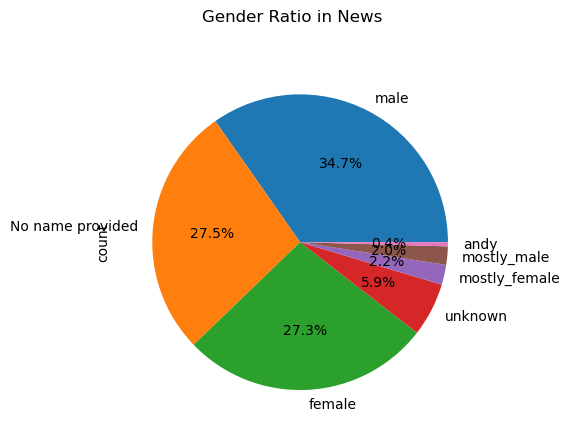

In [12]:
# Pie of gender ratio
fig, ax = plt.subplots()
df["gender"].value_counts().plot.pie(autopct='%1.1f%%')
fig.suptitle("Gender Ratio in News")

Text(0.5, 0.98, 'Gender Ratio in News')

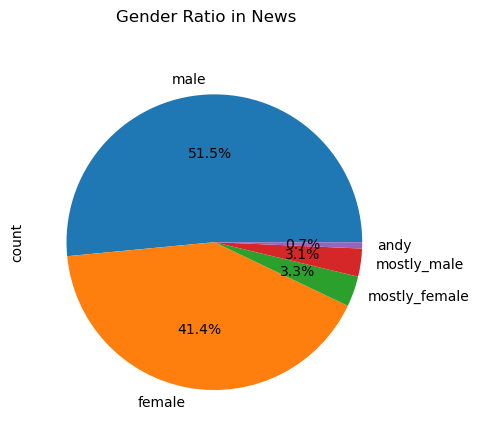

In [13]:
# Drop columns with value "No name provided" or "unknown"
df_gender = df
# drop rows with value "No name provided" or "unknown" in column "gender"
df_gender["gender"].replace("No name provided", np.nan, inplace=True)
df_gender["gender"].replace("unknown", np.nan, inplace=True)
df_gender.dropna(inplace=True)
fig, ax = plt.subplots()
df_gender["gender"].value_counts().plot.pie(autopct='%1.1f%%')
# fig add title
fig.suptitle("Gender Ratio in News")

Which percentage of women write the most important news of the day?


<Axes: ylabel='count'>

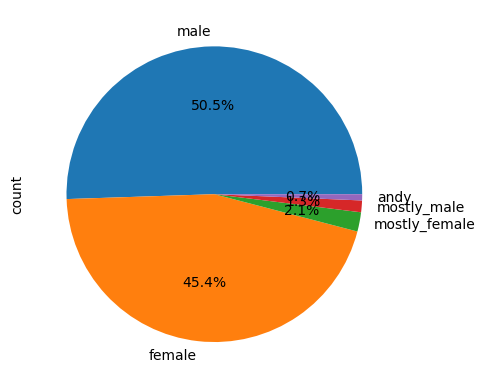

In [14]:
df_gender["gender"][df_gender["idx"]==1].value_counts().plot.pie(autopct='%1.1f%%')

And the top 5?

<Axes: ylabel='count'>

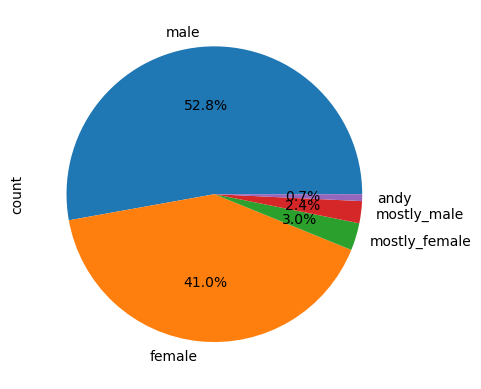

In [15]:
df_gender["gender"][df_gender["idx"]<6].value_counts().plot.pie(autopct='%1.1f%%')

And the top 10?

<Axes: ylabel='count'>

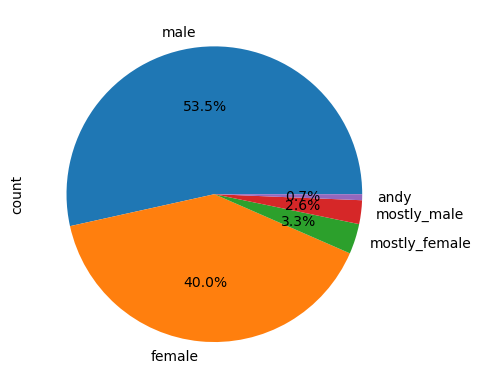

In [16]:
df_gender["gender"][df_gender["idx"]<11].value_counts().plot.pie(autopct='%1.1f%%')

Who do the headlines talk about? Are they mostly men?

Is the sentiment of the headline different depending on the author gender?

In [17]:
gender_sentiment = df.groupby(by="gender")["sentiment_signed"].mean()[["female", "male"]].sort_values(ascending=True)
gender_sentiment

gender
male     -0.514010
female   -0.471363
Name: sentiment_signed, dtype: float64

(0.0, -1.0)

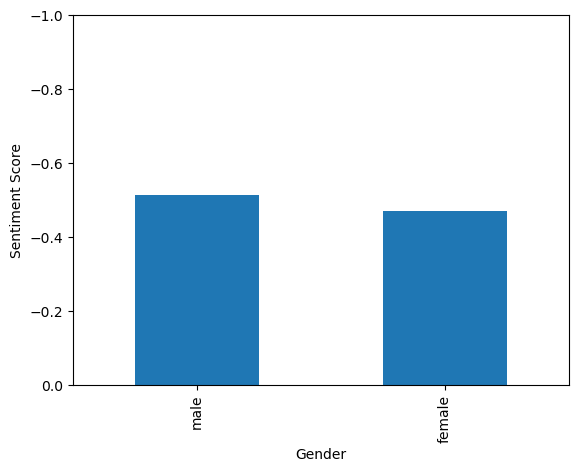

In [18]:
fig, ax = plt.subplots()
gender_sentiment.plot.bar(ax=ax)
ax.set_ylabel("Sentiment Score")
ax.set_xlabel("Gender")
ax.set_ylim(0, -1)


In [19]:
df.groupby(by="gender")["sentiment_score"].std()

gender
andy             0.088438
female           0.100654
male             0.101411
mostly_female    0.098648
mostly_male      0.098018
Name: sentiment_score, dtype: float64

And depending on the gender of the main person in the headline?

## Pandemic

Which effects did the Covid-19 pandemic have in the headlines sentiment?

Text(0.5, 0, 'Date')

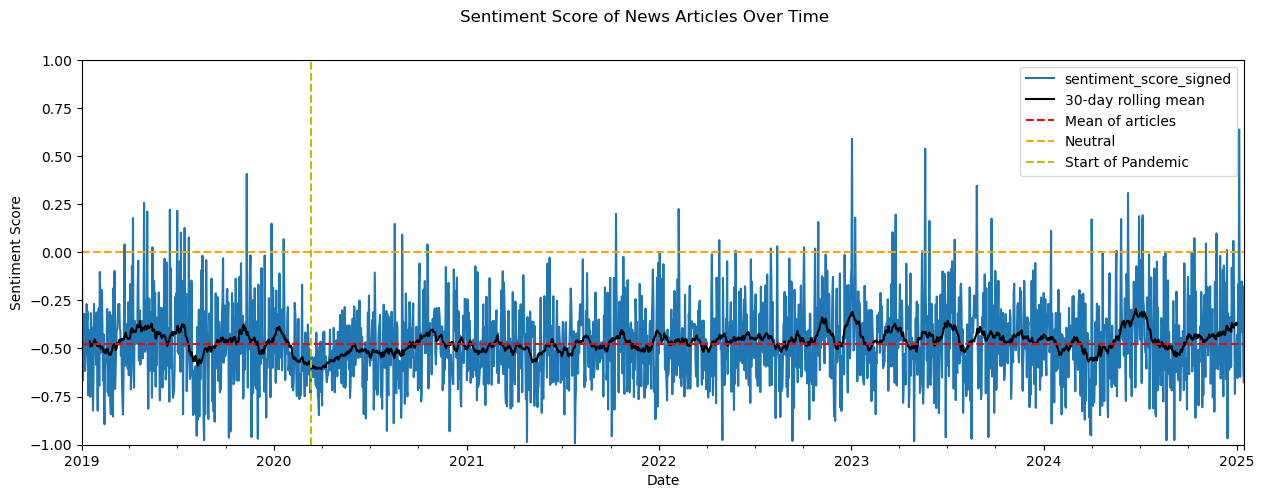

In [37]:
# Create figure
fig, ax = plt.subplots(figsize=(15, 5))
df.groupby(df['date'])["sentiment_score_signed"].mean().plot(kind='line', ax=ax)
df.groupby(df['date'])["sentiment_score_signed"].mean().rolling(window=30, center=True).mean().plot(kind='line', ax=ax, color='k', label='30-day rolling mean')
# add mean
ax.axhline(y=df['sentiment_score_signed'].mean(), color='r', linestyle='--', label='Mean of articles')
ax.axhline(y=0, color='orange', linestyle='--', label='Neutral')
ax.set_ylim(-1, 1)
# add a vertical line at the start of the pandemic as declared by WHO (11th March 2020)
ax.axvline(x='2020-03-11', color='y', linestyle='--', label='Start of Pandemic')
# add legend
ax.legend()
# add title
fig.suptitle("Sentiment Score of News Articles Over Time")
# ad daxis labels
ax.set_ylabel("Sentiment Score")
ax.set_xlabel("Date")

Which countries received most media coverage during the pandemic?

In [28]:
from analysis import compare_occurence

In [29]:
countries_list = ["China", "Italy", "Spain"]# , "Austria", "Brazil", "South Africa"]
" ".join(countries_list)

'China Italy Spain'

In [46]:
countries_df = df[df["topics"].str.contains("|".join(countries_list), case=False, na=False)]


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Comparing China, Italy, Spain'}, xlabel='Time', ylabel='Number of Headlines per month'>)

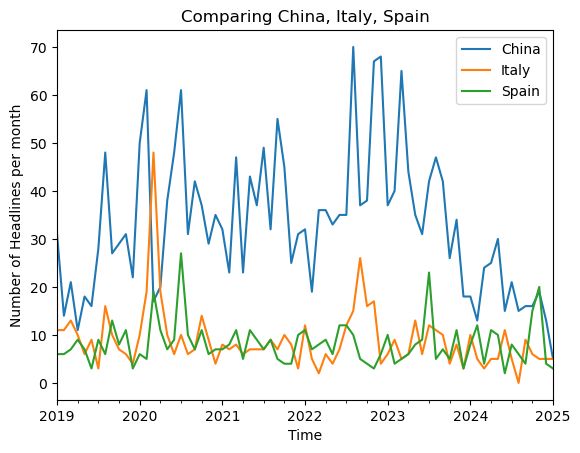

In [47]:
compare_occurence(countries_df, *countries_list)

## International (World News)

Which continents or geographic areas receive most media coverage from The Guardian?

In [178]:
continents = ["Africa", "Asia", "Europe", "America", "Middle East"]
continents_df = df[df["topics"].str.contains("|".join(continents), case=False, na=False)]

# count number of occurences

In [ ]:
geographic_areas = ["Africa", "Asia", "Europe", "America", "Middle East"]
geographic_areas_df = df[df["topics"].str.contains("|".join(geographic_areas), case=False)]

Is there a change of attention to different geographic areas during the length of the dataset (2019-2024)?

In [48]:
compare_occurence(continents_df, *continents)

NameError: name 'continents_df' is not defined

Which coverage do different armed conflicts receive? Are there any biases in the coverage based on the country of origin?

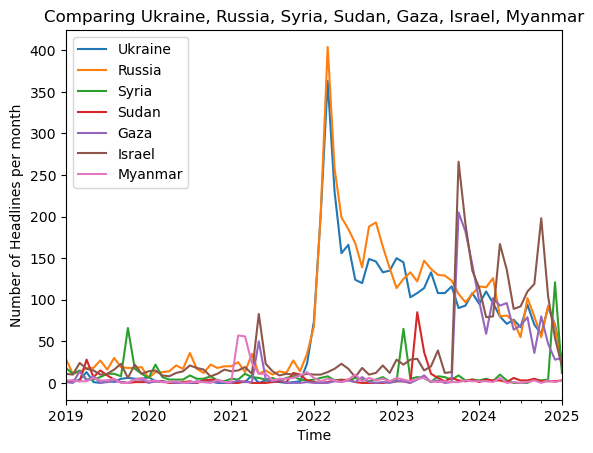

In [180]:
conflicts = ["Ukraine", "Russia", "Syria", "Sudan", "Gaza", "Israel", "Myanmar"]
compare_occurence(df, *conflicts)

Which public figures do get most attention? Is there a temporal evolution?

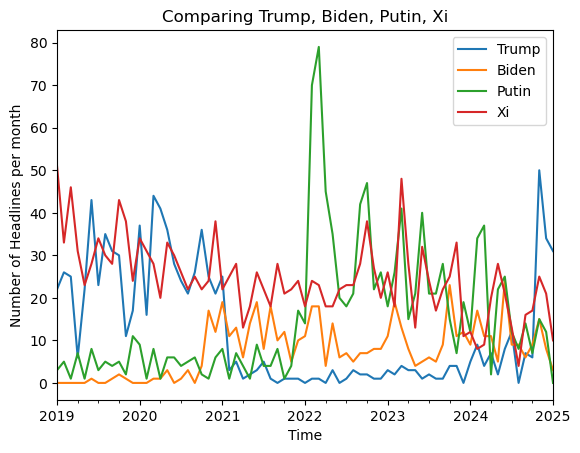

In [186]:
public_figures = ["Trump", "Biden", "Putin", "Xi"]
compare_occurence(df, *public_figures)

How much coverage did Brexit receive, and what was it's temporal evolution?

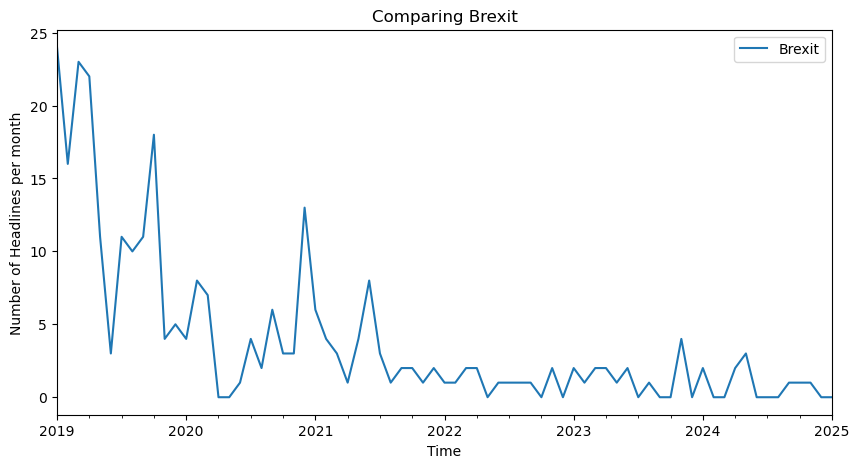

In [7]:
fig, ax = compare_occurence(df, "Brexit")
fig.set_size_inches(10, 5)

Is there a change in sentiment of headlines related to the war in Ukraine and Gaza?

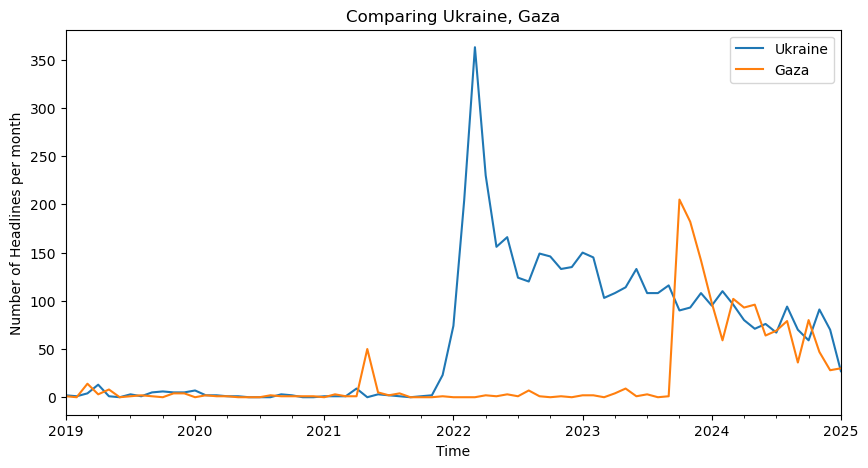

In [8]:
fig, ax = compare_occurence(df, "Ukraine", "Gaza")
fig.set_size_inches(10, 5)

Text(0.5, 0.98, 'Sentiment Score of News Articles on Ukraine Over Time')

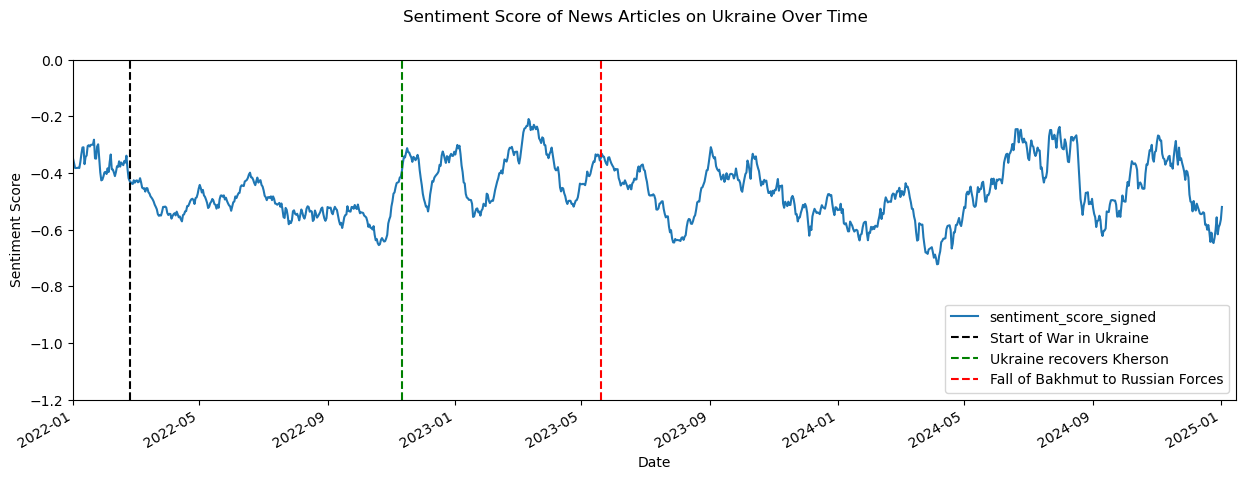

In [115]:
# Group by date and calculate the mean sentiment score per date
sentiment_by_date = ukraine_headlines.groupby(by="date")["sentiment_score_signed"].mean()

# Apply a rolling window of 30 days to the sentiment scores
rolling_mean = sentiment_by_date.rolling(window=30, center=True).mean()


# Plot the rolling mean sentiment score
fig, ax = plt.subplots(figsize=(15, 5))

rolling_mean.plot(kind='line', ax=ax)
ax.axvline(x="2022-02-24", color='k', linestyle='--', label='Start of War in Ukraine')
ax.axvline(x="2022-11-11", color='g', linestyle='--', label='Ukraine recovers Kherson')
ax.axvline(x="2023-05-20", color='r', linestyle='--', label='Fall of Bakhmut to Russian Forces')
ax.legend(loc='lower right')
ax.set_ylim(-1.2, 0)
ax.set_xlim("2022-01-01", "2025-01-15")
# add labels
ax.set_ylabel("Sentiment Score")
ax.set_xlabel("Date")
# add title
fig.suptitle("Sentiment Score of News Articles on Ukraine Over Time")

In [70]:
sentiment_ukraine = pd.DataFrame(index=sentiment_ukraine.index, data=sentiment_ukraine.values, columns=["sentiment_score"])

<Axes: xlabel='year,month'>

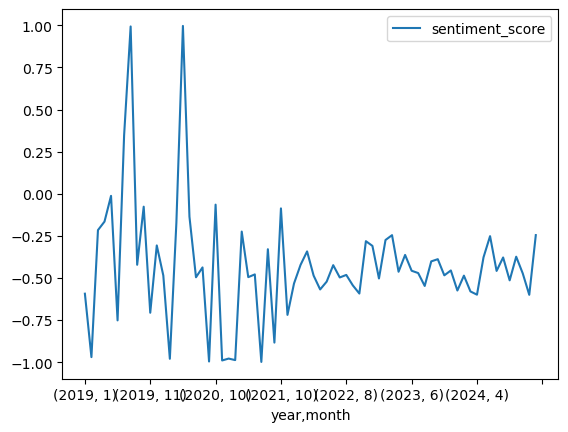

In [72]:
sentiment_ukraine.plot()

## Authors

In [73]:
# Rank the authors that have more negative sentiments in their headlines


In [29]:
# Filter for authors with more than 10 headlines
df_authors = df.groupby('authors').agg({'headline': 'count', 'sentiment_score_signed': 'mean', 'gender': 'first'}).reset_index()

In [30]:
df_authors

,authors,headline,sentiment_score_signed,gender
0,Achilleas Zavallis,1,0.647390,male
1,Adam Gabbatt,4,-0.979357,male
2,Adam Vaughan,1,0.502646,male
3,Adrian Horton,1,0.997494,male
4,Akshata Rao,3,-0.990426,unknown
...,...,...,...,...
215,Vikram Dodd,2,-0.990467,male
216,Virginia López,2,-0.008253,female
217,Vivian Ho,1,-0.975592,female
218,Warren Murray,26,-0.432503,male


In [34]:
# Display authors with more than X articles
minimum_articles = 10
df_authors[df_authors['headline'] > minimum_articles].sort_values(by='headline', ascending=False)

,authors,headline,sentiment_score_signed,gender
149,No author found,490,-0.418593,No name provided
158,Patrick Wintour,55,-0.538916,male
209,Tom Phillips,43,-0.605786,male
15,Angela Giuffrida,37,-0.540439,female
139,Michael Safi,34,-0.379370,male
38,Daniel Boffey,33,-0.629775,male
66,Harriet Sherwood,30,-0.290312,female
100,Justin McCurry,28,-0.370882,male
116,Leyland Cecco,27,0.076709,unknown
218,Warren Murray,26,-0.432503,male


In [35]:
# Get only most prolific authors
df_authors = df_authors[df_authors['headline'] > minimum_articles]

In [36]:
df_authors['sentiment_score_signed'].groupby(df_authors['authors']).mean().sort_values().head(10)

authors
Kate Lyons           -0.810558
Joe Parkin Daniels   -0.753247
Kim Willsher         -0.752845
Bethan McKernan      -0.729527
Lorenzo Tondo        -0.727453
Ed Vulliamy          -0.677105
Andrew Roth          -0.673928
Oliver Holmes        -0.650085
Dom Phillips         -0.641887
Daniel Boffey        -0.629775
Name: sentiment_score_signed, dtype: float64

In [38]:
df_authors['sentiment_score_signed'].groupby(df_authors['authors']).mean().sort_values(ascending=False).head(10)

authors
Leyland Cecco            0.076709
Harriet Sherwood        -0.290312
Helena Smith            -0.313741
Angelique Chrisafis     -0.330785
Justin McCurry          -0.370882
Hannah Ellis-Petersen   -0.371531
Michael Safi            -0.379370
Julian Borger           -0.417396
No author found         -0.418593
Rory Carroll            -0.427286
Name: sentiment_score_signed, dtype: float64

In [19]:
# Let's do a pie chart of gender
df_authors[['sentiment_score_signed', 'gender']].groupby(df_authors['authors']).mean().sort_values(ascending=False).head(10)

KeyError: "['gender'] not in index"